In [ ]:
from google.colab import files
uploaded = files.upload()


In [ ]:
import zipfile
import os

with zipfile.ZipFile("data.zip", 'r') as zip_ref:
  zip_ref.extractall("data")


In [ ]:
import torch
from torch import nn
import torchvision
from torchvision import datasets, transforms
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

In [ ]:
def splitting_folders():
    data_dir = 'data/raw'
    output_base_dir = "data/split"


    categories = os.listdir(data_dir)

    for split in ['train', 'test']:
        for category in categories:
            os.makedirs(os.path.join(output_base_dir, split, category), exist_ok=True)


    test_size = 0.2
    for category in categories:
        image_paths = glob.glob(os.path.join(data_dir, category, "*"))

        train_path, test_path = train_test_split(image_paths, test_size=test_size, random_state=42)

        for path in train_path:
            shutil.copy(path, os.path.join(output_base_dir, "train", category))

        for path in test_path:
            shutil.copy(path, os.path.join(output_base_dir, "test", category))

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:


transform = transforms.Compose([
    transforms.Grayscale(num_output_channels= 1),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])
train_data = datasets.ImageFolder(
    root="data/data/split/train",
    transform=transform
)

test_data = datasets.ImageFolder(
    root="data/data/split/test",
    transform= transform
)

image, label = train_data[0]
print(image, label)
print(image.shape)

tensor([[[-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         ...,
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.]]]) 0
torch.Size([1, 128, 128])


In [ ]:
names_of_classes = train_data.classes

In [ ]:
train_data.class_to_idx

{'MildDemented': 0,
 'ModerateDemented': 1,
 'NonDemented': 2,
 'VeryMildDemented': 3}

In [ ]:
from collections import Counter


train_counts = Counter([label for _, label in train_data])

print(" Liczba obrazów w każdej klasie (TRAIN):")
for cls, idx in train_data.class_to_idx.items():
    print(f"{cls}: {train_counts[idx]}")


test_counts = Counter([label for _, label in test_data])

print("\n Liczba obrazów w każdej klasie (TEST):")
for cls, idx in test_data.class_to_idx.items():
    print(f"{cls}: {test_counts[idx]}")



 Liczba obrazów w każdej klasie (TRAIN):
MildDemented: 716
ModerateDemented: 51
NonDemented: 2560
VeryMildDemented: 1792

 Liczba obrazów w każdej klasie (TEST):
MildDemented: 180
ModerateDemented: 13
NonDemented: 640
VeryMildDemented: 448


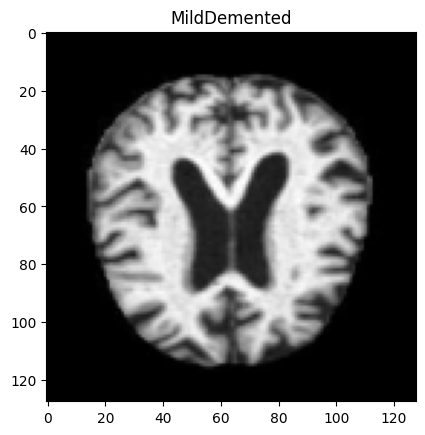

In [ ]:
image, label = train_data[0]
plt.title(label)
plt.title(names_of_classes[label])
plt.imshow(image.squeeze(), cmap='gray')

In [ ]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(
    train_data,
    batch_size = 32,
    shuffle = True
)

test_dataloader = DataLoader(
    test_data,
    batch_size = 32,
    shuffle = False
)

print(f"Length of train dataloader: {len(train_dataloader)}")
print(f"Length of test dataloader: {len(test_dataloader)}")

image, label = train_data[0]
print(image.shape)
print(label)

image_batch, label_batch = next(iter(train_dataloader))
print(image_batch.shape)
print(label_batch)

Length of train dataloader: 160
Length of test dataloader: 41
torch.Size([1, 128, 128])
0
torch.Size([32, 1, 128, 128])
tensor([0, 3, 3, 2, 0, 2, 3, 3, 2, 2, 3, 2, 2, 2, 0, 3, 0, 2, 2, 2, 3, 2, 2, 2,
        2, 3, 2, 2, 2, 3, 2, 0])


In [ ]:
class EarlyStopper:

    def __init__(self, patience=10, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.min_validation_loss = float('inf')
        self.should_stop = False
        self.best_model_state = None

    def __call__(self, validation_loss, model):

        if validation_loss > self.min_validation_loss + self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True

        else:
            self.min_validation_loss = validation_loss
            self.counter = 0

            self.best_model_state = model.state_dict()

        return self.should_stop

    def load_best_weights(self, model):

        if self.best_model_state is not None:
            model.load_state_dict(self.best_model_state)
            return True
        return False

In [ ]:
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc


    from timeit import default_timer as timer
def print_train_time(start: float, end: float, device: torch.device = None):
    total_time = end - start
    print(f"Train time on {device}: {total_time:.3f} seconds")
    return total_time

In [ ]:
torch.manual_seed(42)
def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn):

    model.to(device)
    loss, acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)
            y_pred = model(X)

            loss += loss_fn(y_pred, y)
            acc += accuracy_fn(y_true=y,
                                y_pred=y_pred.argmax(dim=1))

        loss /= len(data_loader)
        acc /= len(data_loader)

    return {"model_name": model.__class__.__name__,
            "model_loss": loss.item(),
            "model_acc": acc}

In [ ]:
def train(model: torch.nn.Module,
    data_loader: torch.utils.data.DataLoader,
    loss_fn: torch.nn.Module,
    optimizer: torch.optim.Optimizer,
    accuracy_fn,
    device: torch.device = device):

    train_loss, train_acc = 0, 0
    model.to(device)
    for batch, (X, y) in enumerate(data_loader):
      X, y = X.to(device), y.to(device)

      y_pred = model(X)

      loss = loss_fn(y_pred, y)
      train_loss += loss
      train_acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%")


def test(model: nn.Module,
         data_loader: torch.utils.data.DataLoader,
         loss_fn: torch.nn.Module,
         accuracy_fn,
         device: torch.device = device
         ):

  test_loss, test_acc = 0, 0
  model.to(device)
  model.eval()
  with torch.inference_mode():
    for X, y in data_loader:
      X, y = X.to(device), y.to(device)
      y_test_pred = model(X)

      test_loss += loss_fn(y_test_pred, y)
      test_acc += accuracy_fn(y_true=y, y_pred=y_test_pred.argmax(dim=1))

    test_loss /= len(data_loader)
    test_acc /= len(data_loader)
    print(f"Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%\n")

In [ ]:
class ModelV2CNN(nn.Module):
  def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
     super().__init__()
     self.block1 = nn.Sequential(
         nn.Conv2d(in_channels=input_shape,
                   out_channels=hidden_units,
                   kernel_size=3,
                   stride=1,
                   padding=1),
         nn.ReLU(),
         nn.Conv2d(in_channels=hidden_units,
                   out_channels=hidden_units,
                   kernel_size=3,
                   stride=1,
                   padding=1),
         nn.ReLU(),
         nn.MaxPool2d(kernel_size=2, stride=2)
     )
     self.block2 = nn.Sequential(
         nn.Conv2d(in_channels=hidden_units,
                   out_channels=hidden_units,
                   kernel_size=3,
                   stride=1,
                   padding=1),
         nn.ReLU(),
         nn.Conv2d(in_channels=hidden_units,
                   out_channels=hidden_units,
                   kernel_size=3,
                   stride=1,
                   padding=1),
         nn.ReLU(),
         nn.MaxPool2d(kernel_size=2, stride=2)
     )
     self.classifier = nn.Sequential(
         nn.Flatten(),
         nn.Linear(in_features=hidden_units*32*32,
                   out_features= output_shape)
     )

  def forward(self, x: torch.Tensor):
    x = self.block1(x)
    #print(x.shape)
    x = self.block2(x)
    #print(x.shape)
    x = self.classifier(x)
    #print(x.shape)
    return x

torch.manual_seed(42)
modelV2 = ModelV2CNN(input_shape=1,
                     hidden_units=64,
                     output_shape=len(names_of_classes)).to(device)

modelV2

ModelV2CNN(
  (block1): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=65536, out_features=4, bias=True)
  )
)

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(modelV2.parameters(), lr=0.01)

In [ ]:
for images, labels in train_dataloader:
    images = images.to(device)
    outputs = modelV2(images)
    break


In [ ]:
torch.manual_seed(42)
from tqdm import tqdm
from timeit import default_timer as timer
train_time_start_model_2 = timer()

epochs = 10
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n---------")
    train(data_loader=train_dataloader,
        model=modelV2,
        loss_fn=loss_fn,
        optimizer=optimizer,
        accuracy_fn=accuracy_fn,
        device=device
    )
    test(data_loader=test_dataloader,
        model=modelV2,
        loss_fn=loss_fn,
        accuracy_fn=accuracy_fn,
        device=device
    )

train_time_end_model_2 = timer()
total_train_time_model_2 = print_train_time(start=train_time_start_model_2,
                                           end=train_time_end_model_2,
                                           device=device)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 0
---------
Train loss: 1.03389 | Train accuracy: 49.60%


 10%|█         | 1/10 [00:10<01:38, 10.97s/it]

Test loss: 0.98022 | Test accuracy: 51.22%

Epoch: 1
---------
Train loss: 0.97816 | Train accuracy: 52.02%


 20%|██        | 2/10 [00:21<01:25, 10.73s/it]

...

Test loss: 0.90970 | Test accuracy: 57.24%

Epoch: 8
---------
Train loss: 0.74465 | Train accuracy: 66.71%


 90%|█████████ | 9/10 [01:35<00:10, 10.61s/it]

Test loss: 0.70573 | Test accuracy: 69.97%

Epoch: 9
---------
Train loss: 0.68674 | Train accuracy: 70.56%


100%|██████████| 10/10 [01:46<00:00, 10.62s/it]

Test loss: 0.68329 | Test accuracy: 69.97%

Train time on cuda: 106.247 seconds


In [ ]:
results_of_model2 = eval_model(model=modelV2,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn)
results_of_model2

{'model_name': 'ModelV2CNN',
 'model_loss': 0.6832899451255798,
 'model_acc': 69.96951219512195}

In [ ]:
import torch
from torch import nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import numpy as np
from sklearn.model_selection import StratifiedKFold
from timeit import default_timer as timer
from tqdm.auto import tqdm
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


class EarlyStopper:
    def __init__(self, patience=10, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.min_validation_loss = float('inf')
        self.should_stop = False
        self.best_model_state = None

    def __call__(self, validation_loss, model):

        if validation_loss < self.min_validation_loss - self.min_delta:
            self.min_validation_loss = validation_loss
            self.counter = 0

            self.best_model_state = model.state_dict()

        elif validation_loss > self.min_validation_loss + self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True

        return self.should_stop

    def load_best_weights(self, model):
        if self.best_model_state is not None:
            model.load_state_dict(self.best_model_state)
            return True
        return False


def train_epoch_hist(model: torch.nn.Module,
    data_loader: torch.utils.data.DataLoader,
    loss_fn: torch.nn.Module,
    optimizer: torch.optim.Optimizer,
    accuracy_fn,
    device: torch.device):

    train_loss, train_acc = 0, 0
    model.to(device)
    model.train()

    for X, y in data_loader:
        X, y = X.to(device), y.to(device)

        y_pred = model(X)

        loss = loss_fn(y_pred, y)
        train_loss += loss.item()
        train_acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    return train_loss, train_acc


def test_epoch_hist(model: nn.Module,
         data_loader: torch.utils.data.DataLoader,
         loss_fn: torch.nn.Module,
         accuracy_fn,
         device: torch.device
         ):

  test_loss, test_acc = 0, 0
  model.to(device)
  model.eval()
  with torch.inference_mode():
    for X, y in data_loader:
      X, y = X.to(device), y.to(device)
      y_test_pred = model(X)

      test_loss += loss_fn(y_test_pred, y).item()
      test_acc += accuracy_fn(y_true=y, y_pred=y_test_pred.argmax(dim=1))

    test_loss /= len(data_loader)
    test_acc /= len(data_loader)
    return test_loss, test_acc

def eval_model(model: torch.nn.Module, data_loader: torch.utils.data.DataLoader, loss_fn: torch.nn.Module, accuracy_fn):
    loss, acc = test_epoch_hist(model, data_loader, loss_fn, accuracy_fn, next(model.parameters()).device)
    return {"model_loss": loss, "model_acc": acc}

def plot_confusion_matrix_subplot(y_true: np.ndarray,
                                  y_pred: np.ndarray,
                                  class_names: list,
                                  fold_num: int,
                                  ax):

    cm = confusion_matrix(y_true, y_pred)

    sns.heatmap(cm,
                annot=True,
                fmt='d',
                cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names,
                ax=ax)
    ax.set_title(f'Fold {fold_num}')
    ax.set_xlabel('Przewidziana Klasa')
    ax.set_ylabel('Rzeczywista Klasa')


def get_predictions_and_labels(model: torch.nn.Module, data_loader: torch.utils.data.DataLoader, device: torch.device):
    model.to(device)
    model.eval()
    y_pred_list = []
    y_true_list = []

    with torch.inference_mode():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)
            y_logits = model(X)
            y_pred_class = torch.argmax(y_logits, dim=1)

            y_pred_list.append(y_pred_class.cpu().numpy())
            y_true_list.append(y.cpu().numpy())

    y_pred_all = np.concatenate(y_pred_list)
    y_true_all = np.concatenate(y_true_list)
    return y_true_all, y_pred_all


from sklearn.metrics import precision_recall_fscore_support, accuracy_score, confusion_matrix

def calculate_advanced_metrics(y_true: np.ndarray, y_pred: np.ndarray, average_mode='weighted'):


    precision, recall, fscore, _ = precision_recall_fscore_support(
        y_true, y_pred, average=average_mode, zero_division=0
    )

    accuracy = accuracy_score(y_true, y_pred)

    return {
        'Precision_W': precision * 100,
        'Recall_W': recall * 100,
        'F1_Score_W': fscore * 100,
        'model_acc': accuracy * 100
    }



Starting 5-Fold Stratified Cross-Validation on train_data with 100 epochs...
Pierwotny rozkład klas: Counter({np.int64(2): 2560, np.int64(3): 1792, np.int64(0): 716, np.int64(1): 51})

--- Fold 1/5 ---


Fold 1:   0%|          | 0/100 [00:00<?, ?it/s]


[EARLY STOPPING] Trening przerwany w epoce 41 z powodu braku poprawy.
Załadowano najlepsze wagi modelu z epoki o najniższej stracie walidacyjnej.
Total training time for Fold 1: 349.913 seconds
Fold 1 Final Validation Results: {'model_loss': 0.16814701013936428, 'model_acc': 94.7265625, 'Precision_W': 94.72223181248246, 'Recall_W': 94.7265625, 'F1_Score_W': 94.71309364454923, 'fold': 1, 'total_time': 349.912965891}

--- Fold 2/5 ---


Fold 2:   0%|          | 0/100 [00:00<?, ?it/s]


[EARLY STOPPING] Trening przerwany w epoce 43 z powodu braku poprawy.
Załadowano najlepsze wagi modelu z epoki o najniższej stracie walidacyjnej.
Total training time for Fold 2: 365.943 seconds
Fold 2 Final Validation Results: {'model_loss': 0.2054451702424558, 'model_acc': 95.21484375, 'Precision_W': 95.20814385900432, 'Recall_W': 95.21484375, 'F1_Score_W': 95.20847290656798, 'fold': 2, 'total_time': 365.94345097199994}

--- Fold 3/5 ---


...


[EARLY STOPPING] Trening przerwany w epoce 34 z powodu braku poprawy.
Załadowano najlepsze wagi modelu z epoki o najniższej stracie walidacyjnej.
Total training time for Fold 3: 289.991 seconds
Fold 3 Final Validation Results: {'model_loss': 0.2654080890933983, 'model_acc': 92.96875, 'Precision_W': 93.02218860361774, 'Recall_W': 92.96875, 'F1_Score_W': 92.96260618428983, 'fold': 3, 'total_time': 289.990676592}

--- Fold 4/5 ---


Fold 4:   0%|          | 0/100 [00:00<?, ?it/s]


[EARLY STOPPING] Trening przerwany w epoce 41 z powodu braku poprawy.
Załadowano najlepsze wagi modelu z epoki o najniższej stracie walidacyjnej.
Total training time for Fold 4: 353.425 seconds
Fold 4 Final Validation Results: {'model_loss': 0.1587814565136796, 'model_acc': 95.5078125, 'Precision_W': 95.50989216443837, 'Recall_W': 95.5078125, 'F1_Score_W': 95.50862358988965, 'fold': 4, 'total_time': 353.42494916400005}

--- Fold 5/5 ---


Fold 5:   0%|          | 0/100 [00:00<?, ?it/s]


[EARLY STOPPING] Trening przerwany w epoce 42 z powodu braku poprawy.
Załadowano najlepsze wagi modelu z epoki o najniższej stracie walidacyjnej.
Total training time for Fold 5: 358.924 seconds
Fold 5 Final Validation Results: {'model_loss': 0.15127104557905113, 'model_acc': 96.28543499511241, 'Precision_W': 96.29439959164442, 'Recall_W': 96.28543499511241, 'F1_Score_W': 96.2855856456333, 'fold': 5, 'total_time': 358.923889571}


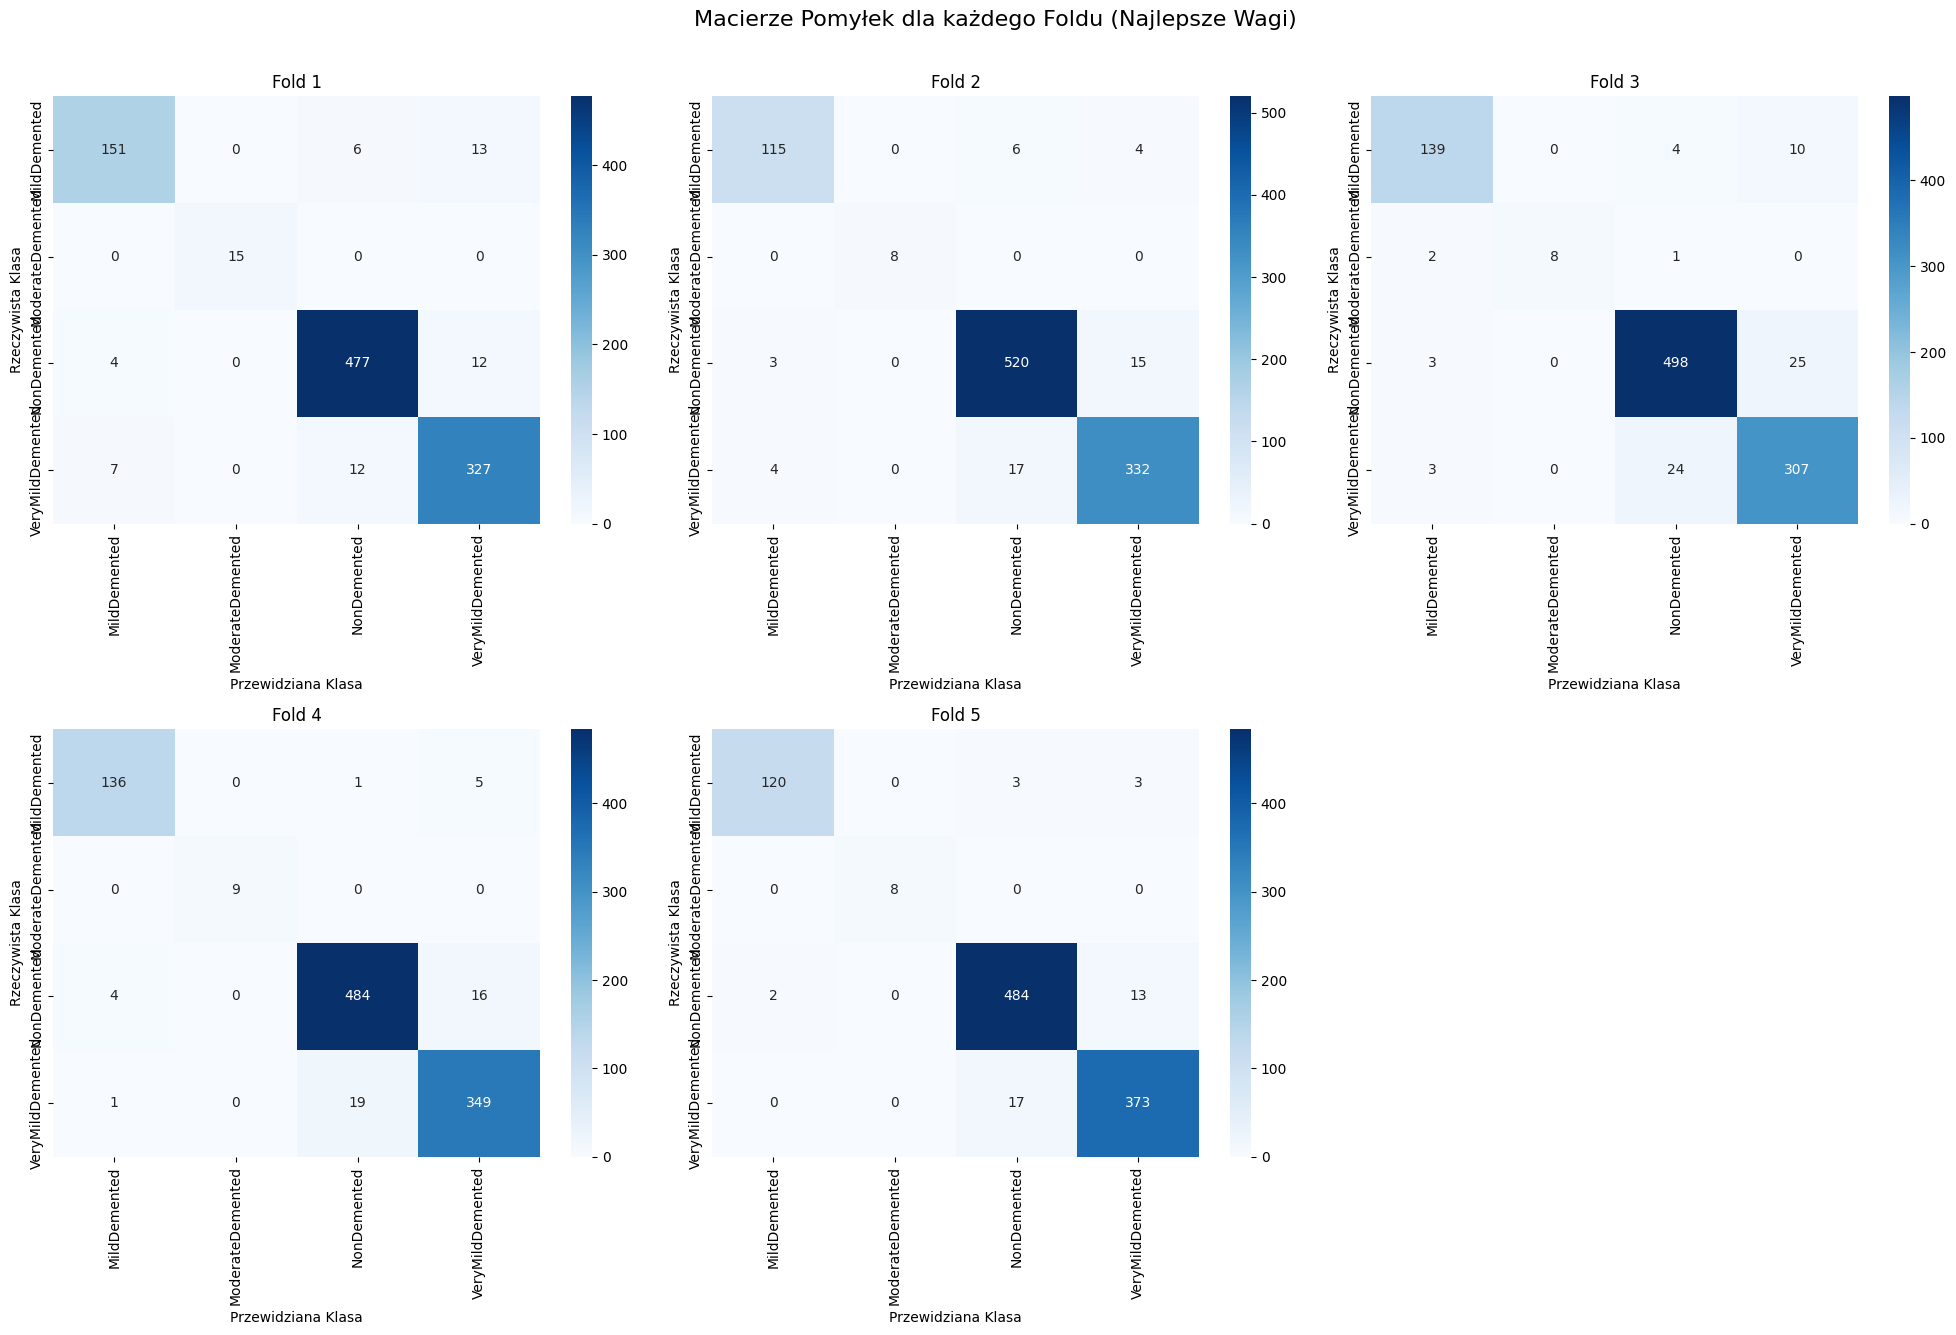

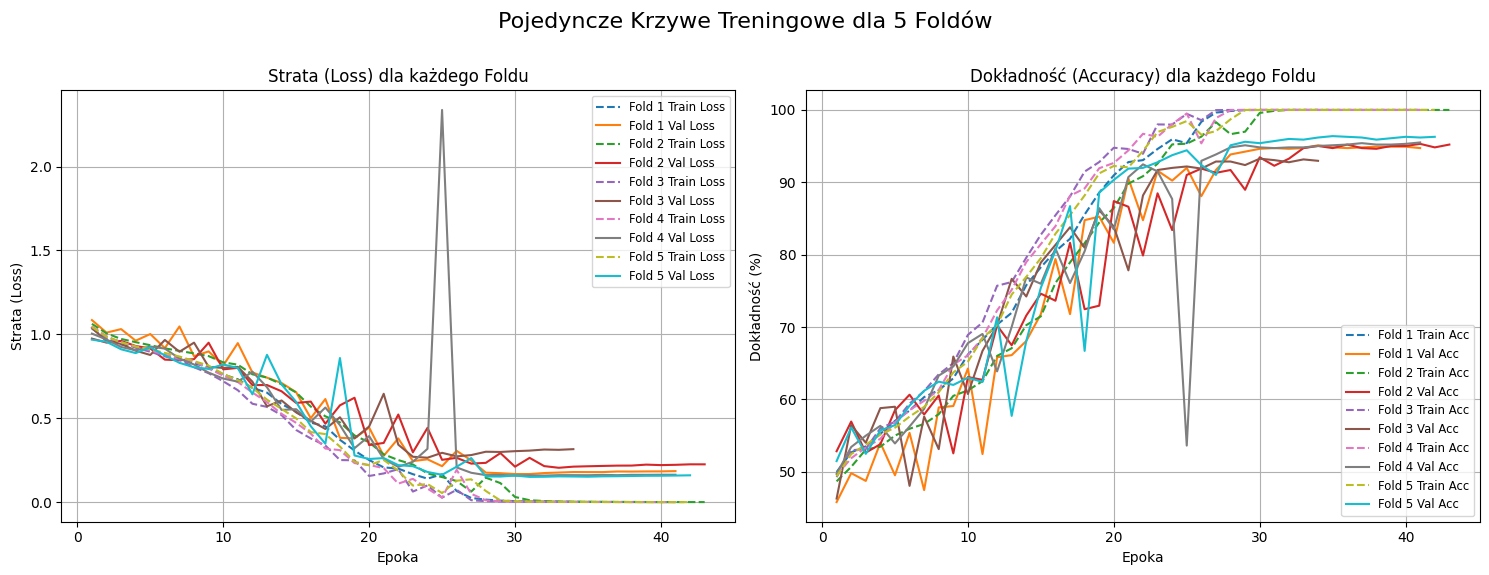

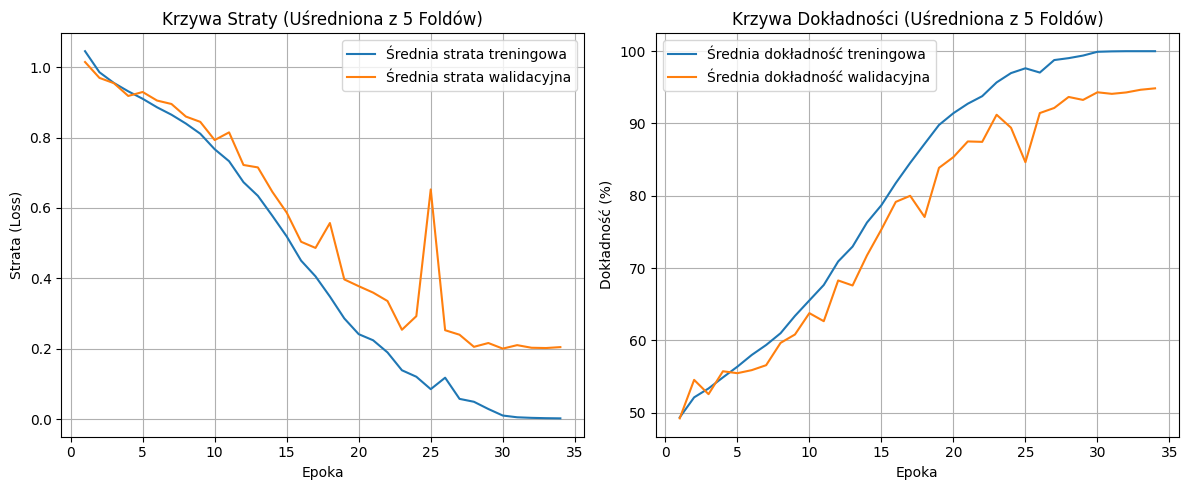


--- K-Fold Cross-Validation Finished ---

Average Results over 5 Folds:
Average Loss: 0.1898
Average Accuracy: 94.94%
Average Precision (Weighted): 94.95%
Average Recall (Weighted): 94.94%
Average F1-Score (Weighted): 94.94%
Average Training Time per Fold: 343.639s

--- Zapisywanie Indeksów i Klas Obrazów ---
 Pomyślnie zapisano listę przypisań obrazów do pliku: kfold_image_assignments.csv

Podgląd pierwszych 5 wierszy zapisanej tabeli:
 Fold   Set                                            Image_Identifier       Class_Name
    1 Train           data/split/train/NonDemented/NonDemented_0721.jpg      NonDemented
    1 Train           data/split/train/NonDemented/NonDemented_1660.jpg      NonDemented
    1 Train data/split/train/VeryMildDemented/VeryMildDemented_0714.jpg VeryMildDemented
    1 Train           data/split/train/NonDemented/NonDemented_1108.jpg      NonDemented
    1 Train data/split/train/VeryMildDemented/VeryMildDemented_0213.jpg VeryMildDemented

Czy każdy obraz trafił 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:

# ==============================================================================
# 1. PRZYGOTOWANIE DANYCH I STRATIFIED K-FOLD
# ==============================================================================

class_names = ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']
class_counts = {0: 716, 1: 51, 2: 2560, 3: 1792}

simulated_data = []
for class_index, count in class_counts.items():
    class_name = class_names[class_index]
    for i in range(count):
        identifier = f"data/split/train/{class_name}/{class_name}_{i+1:04d}.jpg"
        simulated_data.append((identifier, class_index))

np.random.seed(42)
np.random.shuffle(simulated_data)

targets = np.array([item[1] for item in simulated_data])
num_samples = len(targets)
num_classes = len(class_names)
n_splits = 5
EPOCHS = 100

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
results_kfold = []
all_fold_details = []
history_kfold = []

print(f"Starting {n_splits}-Fold Stratified Cross-Validation on train_data with {EPOCHS} epochs...")
print(f"Pierwotny rozkład klas: {Counter(targets)}")

fig_cm, axes_cm = plt.subplots(2, 3, figsize=(20, 14))
axes_cm = axes_cm.flatten()


# ==============================================================================
# 2. GŁÓWNA PĘTLA K-FOLD (TRENING + EARLY STOPPING + MACIERZE Pomyłek) - WERSJA OSTATECZNA
# ==============================================================================

for fold, (train_index, val_index) in enumerate(skf.split(np.zeros(num_samples), targets)):
    fold_num = fold + 1
    print(f"\n--- Fold {fold_num}/{n_splits} ---")


    for index in train_index:
        identifier, class_index = simulated_data[index]
        all_fold_details.append({'Fold': fold_num, 'Set': 'Train', 'Image_Identifier': identifier, 'Class_Name': class_names[class_index]})
    for index in val_index:
        identifier, class_index = simulated_data[index]
        all_fold_details.append({'Fold': fold_num, 'Set': 'Validation', 'Image_Identifier': identifier, 'Class_Name': class_names[class_index]})


    train_subset = Subset(train_data, train_index)
    val_subset = Subset(train_data, val_index)

    train_fold_dataloader = DataLoader(train_subset, batch_size=32, shuffle=True)
    val_fold_dataloader = DataLoader(val_subset, batch_size=32, shuffle=False)

    torch.manual_seed(42 + fold)

    modelV2_fold = ModelV2CNN(input_shape=1, hidden_units=64, output_shape=num_classes).to(device)
    loss_fn_fold = nn.CrossEntropyLoss()
    optimizer_fold = optim.SGD(modelV2_fold.parameters(), lr=0.01)

    early_stopper = EarlyStopper(patience=10, min_delta=0.001)
    fold_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    train_time_start_fold = timer()

    for epoch in tqdm(range(EPOCHS), desc=f"Fold {fold_num}"):

        train_loss, train_acc = train_epoch_hist(
            data_loader=train_fold_dataloader, model=modelV2_fold, loss_fn=loss_fn_fold,
            optimizer=optimizer_fold, accuracy_fn=accuracy_fn, device=device)

        val_loss, val_acc = test_epoch_hist(
            data_loader=val_fold_dataloader, model=modelV2_fold, loss_fn=loss_fn_fold,
            accuracy_fn=accuracy_fn, device=device)

        fold_history['train_loss'].append(train_loss)
        fold_history['train_acc'].append(train_acc)
        fold_history['val_loss'].append(val_loss)
        fold_history['val_acc'].append(val_acc)

        if early_stopper(val_loss, modelV2_fold):
            print(f"\n[EARLY STOPPING] Trening przerwany w epoce {epoch + 1} z powodu braku poprawy.")
            break

    train_time_end_fold = timer()
    total_train_time_fold = train_time_end_fold - train_time_start_fold

    # --- FINALNA EWALUACJA I ZAPIS METRYK ---


    if early_stopper.load_best_weights(modelV2_fold):
        print("Załadowano najlepsze wagi modelu z epoki o najniższej stracie walidacyjnej.")
        final_val_loss = early_stopper.min_validation_loss
    else:

        final_val_loss = val_loss


    y_true, y_pred = get_predictions_and_labels(model=modelV2_fold,
                                                data_loader=val_fold_dataloader,
                                                device=device)


    final_metrics = calculate_advanced_metrics(y_true, y_pred)
    final_precision = final_metrics['Precision_W']
    final_recall = final_metrics['Recall_W']
    final_f1 = final_metrics['F1_Score_W']
    final_val_acc = final_metrics['model_acc']


    plot_confusion_matrix_subplot(y_true, y_pred, names_of_classes, fold_num, axes_cm[fold])


    print(f"Total training time for Fold {fold_num}: {total_train_time_fold:.3f} seconds")

    fold_results = {
        'model_loss': final_val_loss,
        'model_acc': final_val_acc,
        'Precision_W': final_precision,
        'Recall_W': final_recall,
        'F1_Score_W': final_f1
    }

    fold_results.update({'fold': fold_num, 'total_time': total_train_time_fold})
    results_kfold.append(fold_results)
    history_kfold.append(fold_history)
    print(f"Fold {fold_num} Final Validation Results: {fold_results}")


# ==============================================================================
# 3. WIZUALIZACJE
# ==============================================================================

# WIZUALIZACJA 1: MACIERZE POMYŁEK (5 WIDOKÓW)
axes_cm[5].set_visible(False)
fig_cm.suptitle('Macierze Pomyłek dla każdego Foldu (Najlepsze Wagi)', fontsize=16)
fig_cm.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

# WIZUALIZACJA 2: POJEDYNCZE KRZYWE TRENINGOWE (5 KRZYWYCH)
fig_hist, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(15, 6))

for fold_num, history in enumerate(history_kfold):
    epochs_run = len(history['train_loss'])
    x_axis = range(1, epochs_run + 1)

    # KRZYWA STRATY (LOSS)
    ax_loss.plot(x_axis, history['train_loss'], label=f'Fold {fold_num+1} Train Loss', linestyle='--')
    ax_loss.plot(x_axis, history['val_loss'], label=f'Fold {fold_num+1} Val Loss', linestyle='-')

    # KRZYWA DOKŁADNOŚCI (ACCURACY)
    ax_acc.plot(x_axis, history['train_acc'], label=f'Fold {fold_num+1} Train Acc', linestyle='--')
    ax_acc.plot(x_axis, history['val_acc'], label=f'Fold {fold_num+1} Val Acc', linestyle='-')


ax_loss.set_title('Strata (Loss) dla każdego Foldu')
ax_loss.set_xlabel('Epoka')
ax_loss.set_ylabel('Strata (Loss)')
ax_loss.legend(loc='upper right', fontsize='small')
ax_loss.grid(True)

ax_acc.set_title('Dokładność (Accuracy) dla każdego Foldu')
ax_acc.set_xlabel('Epoka')
ax_acc.set_ylabel('Dokładność (%)')
ax_acc.legend(loc='lower right', fontsize='small')
ax_acc.grid(True)

fig_hist.suptitle('Pojedyncze Krzywe Treningowe dla 5 Foldów', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

# WIZUALIZACJA 3: UŚREDNIONE KRZYWE TRENINGOWE
max_epochs_run = max(len(h['train_loss']) for h in history_kfold)


avg_history = {
    'train_loss': np.mean([np.pad(h['train_loss'], (0, max_epochs_run - len(h['train_loss'])), 'constant', constant_values=np.nan) for h in history_kfold], axis=0),
    'val_loss': np.mean([np.pad(h['val_loss'], (0, max_epochs_run - len(h['val_loss'])), 'constant', constant_values=np.nan) for h in history_kfold], axis=0),
    'train_acc': np.mean([np.pad(h['train_acc'], (0, max_epochs_run - len(h['train_acc'])), 'constant', constant_values=np.nan) for h in history_kfold], axis=0),
    'val_acc': np.mean([np.pad(h['val_acc'], (0, max_epochs_run - len(h['val_acc'])), 'constant', constant_values=np.nan) for h in history_kfold], axis=0)
}

plt.figure(figsize=(12, 5))


plt.subplot(1, 2, 1)
plt.plot(range(1, max_epochs_run + 1), avg_history['train_loss'], label='Średnia strata treningowa')
plt.plot(range(1, max_epochs_run + 1), avg_history['val_loss'], label='Średnia strata walidacyjna')
plt.title(f'Krzywa Straty (Uśredniona z {n_splits} Foldów)')
plt.xlabel('Epoka')
plt.ylabel('Strata (Loss)')
plt.legend()
plt.grid(True)


plt.subplot(1, 2, 2)
plt.plot(range(1, max_epochs_run + 1), avg_history['train_acc'], label='Średnia dokładność treningowa')
plt.plot(range(1, max_epochs_run + 1), avg_history['val_acc'], label='Średnia dokładność walidacyjna')
plt.title(f'Krzywa Dokładności (Uśredniona z {n_splits} Foldów)')
plt.xlabel('Epoka')
plt.ylabel('Dokładność (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("\n--- K-Fold Cross-Validation Finished ---")


avg_loss = np.mean([res['model_loss'] for res in results_kfold])
avg_acc = np.mean([res['model_acc'] for res in results_kfold])
avg_precision = np.mean([res['Precision_W'] for res in results_kfold])
avg_recall = np.mean([res['Recall_W'] for res in results_kfold])
avg_f1 = np.mean([res['F1_Score_W'] for res in results_kfold])
avg_time = np.mean([res['total_time'] for res in results_kfold])

print(f"\nAverage Results over {n_splits} Folds:")
print(f"Average Loss: {avg_loss:.4f}")
print(f"Average Accuracy: {avg_acc:.2f}%")
print(f"Average Precision (Weighted): {avg_precision:.2f}%")
print(f"Average Recall (Weighted): {avg_recall:.2f}%")
print(f"Average F1-Score (Weighted): {avg_f1:.2f}%")
print(f"Average Training Time per Fold: {avg_time:.3f}s")

# ==============================================================================
# 4. ZAPIS PRZYPISAŃ OBRAZÓW DO PLIKU
# ==============================================================================

print("\n--- Zapisywanie Indeksów i Klas Obrazów ---")

df_all_fold_details = pd.DataFrame(all_fold_details)

filename = 'kfold_image_assignments.csv'
df_all_fold_details.to_csv(filename, index=False)

print(f" Pomyślnie zapisano listę przypisań obrazów do pliku: {filename}")

print("\nPodgląd pierwszych 5 wierszy zapisanej tabeli:")
print(df_all_fold_details.head().to_string(index=False))

num_samples = len(targets)
expected_validation_count = 1
validation_counts = df_all_fold_details[df_all_fold_details['Set'] == 'Validation']['Image_Identifier'].value_counts()
is_perfect_split = all(validation_counts == expected_validation_count)
print(f"\nCzy każdy obraz trafił do zbioru walidacyjnego dokładnie raz (potwierdzenie Stratified K-Fold)? {is_perfect_split}")

# ==============================================================================
# 5. GENEROWANIE TABELI WYNIKÓW (DO ROZDZIAŁU 6.3)
# ==============================================================================
import pandas as pd


df_results = pd.DataFrame(results_kfold)


df_table = df_results[['fold', 'model_loss', 'model_acc', 'Precision_W', 'Recall_W', 'F1_Score_W']].copy()


df_table.columns = [
    'Numer Foldu',
    'Strata (Loss)',
    'Dokładność (Accuracy) [%]',
    'Precyzja (Precision) [%]',
    'Czułość (Recall) [%]',
    'Miara F1 (F1-Score) [%]'
]


mean_values = df_table.mean(numeric_only=True)


mean_row = pd.DataFrame([mean_values], columns=df_table.columns)

mean_row['Numer Foldu'] = 'ŚREDNIA'


df_final = pd.concat([df_table, mean_row], ignore_index=True)


df_final['Strata (Loss)'] = df_final['Strata (Loss)'].round(4)

cols_percent = [
    'Dokładność (Accuracy) [%]',
    'Precyzja (Precision) [%]',
    'Czułość (Recall) [%]',
    'Miara F1 (F1-Score) [%]'
]
df_final[cols_percent] = df_final[cols_percent].round(2)

print("\n=== PODGLĄD TABELI (Skopiuj wartości lub pobierz plik) ===")
print(df_final.to_string(index=False))

output_excel = 'Wyniki_Do_Pracy_Tabela_6.3.xlsx'
output_csv = 'Wyniki_Do_Pracy_Tabela_6.3.csv'


try:
    df_final.to_excel(output_excel, index=False)
    print(f"\n[SUKCES] Zapisano tabelę do pliku Excel: {output_excel}")
    print("-> Możesz go pobrać, otworzyć i skopiować tabelkę prosto do Worda.")
except Exception as e:
    print(f"\n[INFO] Nie udało się zapisać do Excela ({e}). Zapisuję do CSV.")


df_final.to_csv(output_csv, index=False, sep=';', encoding='utf-8-sig')
print(f"[SUKCES] Zapisano tabelę do pliku CSV: {output_csv}")


try:
    from google.colab import files
    files.download(output_csv)
    files.download(output_excel)
except ImportError:
    pass

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report
from sklearn.preprocessing import label_binarize
from google.colab import files
import torch.nn.functional as F

print("--- GENEROWANIE 3 OSOBNYCH WYKRESÓW DLA ZBIORU TESTOWEGO ---")


modelV2_fold.eval()
y_pred_list = []
y_true_list = []
y_probs_list = []

print("Obliczanie predykcji...")
with torch.inference_mode():
    for X, y in test_dataloader:
        X, y = X.to(device), y.to(device)
        logits = modelV2_fold(X)
        probs = F.softmax(logits, dim=1)

        y_probs_list.append(probs.cpu().numpy())
        y_true_list.append(y.cpu().numpy())
        y_pred_list.append(logits.argmax(dim=1).cpu().numpy())

y_true_test = np.concatenate(y_true_list)
y_pred_test = np.concatenate(y_pred_list)
y_probs_test = np.concatenate(y_probs_list)

# ==========================================
# WYKRES 1: MACIERZ POMYŁEK (NIEBIESKA)
# ==========================================
print("\n1. Generowanie Macierzy Pomyłek...")
plt.figure(figsize=(8, 6)) # Nowa, pusta figura
cm = confusion_matrix(y_true_test, y_pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Macierz Pomyłek dla Zbioru Testowego')
plt.xlabel('Przewidziana Klasa')
plt.ylabel('Rzeczywista Klasa')

filename_cm = 'Macierz_Testowa_Blues.png'
plt.savefig(filename_cm, dpi=300, bbox_inches='tight')
plt.close()
print(f"-> Zapisano i pobieranie: {filename_cm}")
files.download(filename_cm)


# ==========================================
# WYKRES 2: KRZYWE ROC (Multiclass)
# ==========================================
print("\n2. Generowanie Krzywych ROC...")
y_test_bin = label_binarize(y_true_test, classes=[0, 1, 2, 3])
n_classes = y_test_bin.shape[1]

plt.figure(figsize=(10, 8))
colors = ['aqua', 'darkorange', 'cornflowerblue', 'green']

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_probs_test[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2,
             label=f'Klasa {class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Odsetek fałszywie pozytywnych)')
plt.ylabel('True Positive Rate (Czułość)')
plt.title('Krzywe ROC dla Zbioru Testowego')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

filename_roc = 'Krzywe_ROC_Test.png'
plt.savefig(filename_roc, dpi=300, bbox_inches='tight')
plt.close()
print(f"-> Zapisano i pobieranie: {filename_roc}")
files.download(filename_roc)


# ==========================================
# WYKRES 3: METRYKI SŁUPKOWE
# ==========================================
print("\n3. Generowanie Wykresu Słupkowego Metryk...")
report = classification_report(y_true_test, y_pred_test, target_names=class_names, output_dict=True)
df_report = pd.DataFrame(report).transpose()
df_classes = df_report.iloc[:4][['precision', 'recall', 'f1-score']]

plt.figure(figsize=(10, 6))
ax = df_classes.plot(kind='bar', figsize=(10, 6), colormap='viridis', edgecolor='black', width=0.8)
plt.title('Szczegółowe metryki dla poszczególnych klas dla Zbioru Testowego')
plt.ylabel('Wartość (0-1)')
plt.xlabel('Klasa')
plt.ylim(0, 1.15)
plt.legend(loc='lower right', title='Metryka', framealpha=0.9)
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=0)


for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=9)

filename_bar = 'Metryki_Klas_Test.png'
plt.savefig(filename_bar, dpi=300, bbox_inches='tight')
plt.close()
print(f"-> Zapisano i pobieranie: {filename_bar}")
files.download(filename_bar)

print("\n--- ZAKOŃCZONO ---")

--- GENEROWANIE 3 OSOBNYCH WYKRESÓW DLA ZBIORU TESTOWEGO ---
Obliczanie predykcji...

1. Generowanie Macierzy Pomyłek...
-> Zapisano i pobieranie: Macierz_Testowa_Blues.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


2. Generowanie Krzywych ROC...
-> Zapisano i pobieranie: Krzywe_ROC_Test.png


<IPython.core.display.Javascript object>

...


3. Generowanie Wykresu Słupkowego Metryk...
-> Zapisano i pobieranie: Metryki_Klas_Test.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


--- ZAKOŃCZONO ---


<Figure size 1000x600 with 0 Axes>

In [ ]:
# import torch
# from torch import nn, optim
# from torch.utils.data import DataLoader, Subset, Dataset
# from sklearn.model_selection import StratifiedKFold
# import numpy as np
# import matplotlib.pyplot as plt
# import pandas as pd
# from collections import Counter
# from timeit import default_timer as timer
# from tqdm.auto import tqdm

# # Ustawienie globalne: większe czcionki na wykresach
# plt.rcParams.update({'font.size': 12})

# # ==============================================================================
# # 1. PRZYGOTOWANIE DANYCH I STRATIFIED K-FOLD
# # ==============================================================================

# class_names = ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']
# # Symulujemy Twoje dane (bo nie mam dostępu do Twoich plików)
# class_counts = {0: 716, 1: 51, 2: 2560, 3: 1792}

# simulated_data = []
# for class_index, count in class_counts.items():
#     class_name = class_names[class_index]
#     for i in range(count):
#         identifier = f"data/split/train/{class_name}/{class_name}_{i+1:04d}.jpg"
#         simulated_data.append((identifier, class_index))

# np.random.seed(42)
# np.random.shuffle(simulated_data)

# targets = np.array([item[1] for item in simulated_data])
# num_samples = len(targets)
# num_classes = len(class_names)
# n_splits = 5
# EPOCHS = 100

# skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
# results_kfold = []
# all_fold_details = []
# history_kfold = []

# print(f"Starting {n_splits}-Fold Stratified Cross-Validation on train_data with {EPOCHS} epochs...")
# print(f"Pierwotny rozkład klas: {Counter(targets)}")


# # ==============================================================================
# # 2. GŁÓWNA PĘTLA K-FOLD (TRENING + ZAPIS MACIERZY DO OSOBNYCH PLIKÓW)
# # ==============================================================================

# for fold, (train_index, val_index) in enumerate(skf.split(np.zeros(num_samples), targets)):
#     fold_num = fold + 1
#     print(f"\n--- Fold {fold_num}/{n_splits} ---")

#     # A. Zapisywanie identyfikatorów
#     for index in train_index:
#         identifier, class_index = simulated_data[index]
#         all_fold_details.append({'Fold': fold_num, 'Set': 'Train', 'Image_Identifier': identifier, 'Class_Name': class_names[class_index]})
#     for index in val_index:
#         identifier, class_index = simulated_data[index]
#         all_fold_details.append({'Fold': fold_num, 'Set': 'Validation', 'Image_Identifier': identifier, 'Class_Name': class_names[class_index]})

#     # B. Trening modelu - Przygotowanie DataLoaderów
#     # UWAGA: Tutaj musisz mieć zdefiniowaną swoją klasę Dataset (np. 'train_data' z wcześniejszych komórek)
#     # Ponieważ nie mam Twojego obiektu train_data, używam placeholderów w komentarzu,
#     # ale Twój kod zadziała, jeśli 'train_data' jest zdefiniowane wyżej w notatniku.

#     train_subset = Subset(train_data, train_index) # Upewnij się, że train_data istnieje!
#     val_subset = Subset(train_data, val_index)

#     train_fold_dataloader = DataLoader(train_subset, batch_size=32, shuffle=True)
#     val_fold_dataloader = DataLoader(val_subset, batch_size=32, shuffle=False)

#     torch.manual_seed(42 + fold)

#     # Inicjalizacja modelu (Upewnij się, że klasa ModelV2CNN jest zdefiniowana)
#     modelV2_fold = ModelV2CNN(input_shape=1, hidden_units=64, output_shape=num_classes).to(device)
#     loss_fn_fold = nn.CrossEntropyLoss()
#     optimizer_fold = optim.SGD(modelV2_fold.parameters(), lr=0.01)

#     early_stopper = EarlyStopper(patience=10, min_delta=0.001)
#     fold_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

#     train_time_start_fold = timer()

#     # Pętla epok
#     for epoch in tqdm(range(EPOCHS), desc=f"Fold {fold_num}"):
#         train_loss, train_acc = train_epoch_hist(
#             data_loader=train_fold_dataloader, model=modelV2_fold, loss_fn=loss_fn_fold,
#             optimizer=optimizer_fold, accuracy_fn=accuracy_fn, device=device)

#         val_loss, val_acc = test_epoch_hist(
#             data_loader=val_fold_dataloader, model=modelV2_fold, loss_fn=loss_fn_fold,
#             accuracy_fn=accuracy_fn, device=device)

#         fold_history['train_loss'].append(train_loss)
#         fold_history['train_acc'].append(train_acc)
#         fold_history['val_loss'].append(val_loss)
#         fold_history['val_acc'].append(val_acc)

#         if early_stopper(val_loss, modelV2_fold):
#             print(f"\n[EARLY STOPPING] Trening przerwany w epoce {epoch + 1}.")
#             break

#     train_time_end_fold = timer()
#     total_train_time_fold = train_time_end_fold - train_time_start_fold

#     # --- FINALNA EWALUACJA ---
#     if early_stopper.load_best_weights(modelV2_fold):
#         print("Załadowano najlepsze wagi modelu.")
#         final_val_loss = early_stopper.min_validation_loss
#     else:
#         final_val_loss = val_loss

#     y_true, y_pred = get_predictions_and_labels(model=modelV2_fold,
#                                                 data_loader=val_fold_dataloader,
#                                                 device=device)

#     final_metrics = calculate_advanced_metrics(y_true, y_pred)

#     # --- ZAPIS MACIERZY POMYŁEK DO OSOBNEGO PLIKU ---
#     # Tworzymy nową figurę tylko dla tej macierzy
#     fig_cm_fold = plt.figure(figsize=(8, 6))
#     ax_cm_fold = fig_cm_fold.add_subplot(1, 1, 1)

#     # Rysowanie na konkretnej osi ax_cm_fold
#     plot_confusion_matrix_subplot(y_true, y_pred, class_names, fold_num, ax_cm_fold)

#     filename_cm = f'Macierz_Fold_{fold_num}.png'
#     fig_cm_fold.tight_layout()
#     fig_cm_fold.savefig(filename_cm, dpi=300, bbox_inches='tight')
#     plt.close(fig_cm_fold) # Zamknij figurę, żeby nie wyświetlała się w notatniku 5 razy
#     print(f"-> Zapisano macierz pomyłek: {filename_cm}")

#     print(f"Total training time for Fold {fold_num}: {total_train_time_fold:.3f} seconds")

#     fold_results = {
#         'model_loss': final_val_loss,
#         'model_acc': final_metrics['model_acc'],
#         'Precision_W': final_metrics['Precision_W'],
#         'Recall_W': final_metrics['Recall_W'],
#         'F1_Score_W': final_metrics['F1_Score_W'],
#         'fold': fold_num,
#         'total_time': total_train_time_fold
#     }
#     results_kfold.append(fold_results)
#     history_kfold.append(fold_history)
#     print(f"Fold {fold_num} Final Validation Results: {fold_results}")


# # ==============================================================================
# # 3. WIZUALIZACJE ZBIORCZE (ZAPIS DO 4 OSOBNYCH PLIKÓW)
# # ==============================================================================

# print("\nGenerowanie wykresów zbiorczych...")

# # Przygotowanie danych do średnich
# max_epochs_run = max(len(h['train_loss']) for h in history_kfold)
# avg_history = {
#     'train_loss': np.mean([np.pad(h['train_loss'], (0, max_epochs_run - len(h['train_loss'])), 'constant', constant_values=np.nan) for h in history_kfold], axis=0),
#     'val_loss': np.mean([np.pad(h['val_loss'], (0, max_epochs_run - len(h['val_loss'])), 'constant', constant_values=np.nan) for h in history_kfold], axis=0),
#     'train_acc': np.mean([np.pad(h['train_acc'], (0, max_epochs_run - len(h['train_acc'])), 'constant', constant_values=np.nan) for h in history_kfold], axis=0),
#     'val_acc': np.mean([np.pad(h['val_acc'], (0, max_epochs_run - len(h['val_acc'])), 'constant', constant_values=np.nan) for h in history_kfold], axis=0)
# }
# x_axis_avg = range(1, max_epochs_run + 1)


# # --- WYKRES 1: WSZYSTKIE FOLDY - STRATA (LOSS) ---
# plt.figure(figsize=(10, 6))
# for fold_num, history in enumerate(history_kfold):
#     x_axis = range(1, len(history['train_loss']) + 1)
#     plt.plot(x_axis, history['train_loss'], linestyle='--', alpha=0.5, label=f'F{fold_num+1} Train')
#     plt.plot(x_axis, history['val_loss'], linestyle='-', alpha=0.5, label=f'F{fold_num+1} Val')
# plt.title('Przebieg funkcji straty (wszystkie foldy)')
# plt.xlabel('Epoka')
# plt.ylabel('Strata (Loss)')
# plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left", fontsize='small')
# plt.grid(True)
# plt.savefig('Wykres_1_WszystkieFoldy_Loss.png', dpi=300, bbox_inches='tight')
# plt.show()
# print("-> Zapisano: Wykres_1_WszystkieFoldy_Loss.png")


# # --- WYKRES 2: WSZYSTKIE FOLDY - DOKŁADNOŚĆ (ACCURACY) ---
# plt.figure(figsize=(10, 6))
# for fold_num, history in enumerate(history_kfold):
#     x_axis = range(1, len(history['train_acc']) + 1)
#     plt.plot(x_axis, history['train_acc'], linestyle='--', alpha=0.5, label=f'F{fold_num+1} Train')
#     plt.plot(x_axis, history['val_acc'], linestyle='-', alpha=0.5, label=f'F{fold_num+1} Val')
# plt.title('Przebieg dokładności (wszystkie foldy)')
# plt.xlabel('Epoka')
# plt.ylabel('Dokładność (%)')
# plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left", fontsize='small')
# plt.grid(True)
# plt.savefig('Wykres_2_WszystkieFoldy_Acc.png', dpi=300, bbox_inches='tight')
# plt.show()
# print("-> Zapisano: Wykres_2_WszystkieFoldy_Acc.png")


# # --- WYKRES 3: ŚREDNIA STRATA (AVG LOSS) ---
# plt.figure(figsize=(8, 6))
# plt.plot(x_axis_avg, avg_history['train_loss'], label='Średnia strata treningowa', color='blue', linestyle='--')
# plt.plot(x_axis_avg, avg_history['val_loss'], label='Średnia strata walidacyjna', color='red', linestyle='-')
# plt.title(f'Średnia funkcja straty (z {n_splits} foldów)')
# plt.xlabel('Epoka')
# plt.ylabel('Strata (Loss)')
# plt.legend()
# plt.grid(True)
# plt.savefig('Wykres_3_Srednia_Loss.png', dpi=300, bbox_inches='tight')
# plt.show()
# print("-> Zapisano: Wykres_3_Srednia_Loss.png")


# # --- WYKRES 4: ŚREDNIA DOKŁADNOŚĆ (AVG ACCURACY) ---
# plt.figure(figsize=(8, 6))
# plt.plot(x_axis_avg, avg_history['train_acc'], label='Średnia dokładność treningowa', color='blue', linestyle='--')
# plt.plot(x_axis_avg, avg_history['val_acc'], label='Średnia dokładność walidacyjna', color='red', linestyle='-')
# plt.title(f'Średnia dokładność (z {n_splits} foldów)')
# plt.xlabel('Epoka')
# plt.ylabel('Dokładność (%)')
# plt.legend()
# plt.grid(True)
# plt.savefig('Wykres_4_Srednia_Acc.png', dpi=300, bbox_inches='tight')
# plt.show()
# print("-> Zapisano: Wykres_4_Srednia_Acc.png")

# print("\n--- K-Fold Cross-Validation Finished ---")

# # Obliczenie średnich
# avg_loss = np.mean([res['model_loss'] for res in results_kfold])
# avg_acc = np.mean([res['model_acc'] for res in results_kfold])
# avg_precision = np.mean([res['Precision_W'] for res in results_kfold])
# avg_recall = np.mean([res['Recall_W'] for res in results_kfold])
# avg_f1 = np.mean([res['F1_Score_W'] for res in results_kfold])
# avg_time = np.mean([res['total_time'] for res in results_kfold])

# print(f"\nAverage Results over {n_splits} Folds:")
# print(f"Average Loss: {avg_loss:.4f}")
# print(f"Average Accuracy: {avg_acc:.2f}%")
# print(f"Average Precision (Weighted): {avg_precision:.2f}%")
# print(f"Average Recall (Weighted): {avg_recall:.2f}%")
# print(f"Average F1-Score (Weighted): {avg_f1:.2f}%")
# print(f"Average Training Time per Fold: {avg_time:.3f}s")

# # ==============================================================================
# # 4. ZAPIS PRZYPISAŃ OBRAZÓW DO PLIKU
# # ==============================================================================

# print("\n--- Zapisywanie Indeksów i Klas Obrazów ---")
# df_all_fold_details = pd.DataFrame(all_fold_details)
# filename = 'kfold_image_assignments.csv'
# df_all_fold_details.to_csv(filename, index=False)
# print(f" Pomyślnie zapisano listę przypisań obrazów do pliku: {filename}")

# num_samples = len(targets)
# expected_validation_count = 1
# validation_counts = df_all_fold_details[df_all_fold_details['Set'] == 'Validation']['Image_Identifier'].value_counts()
# is_perfect_split = all(validation_counts == expected_validation_count)
# print(f"\nCzy każdy obraz trafił do zbioru walidacyjnego dokładnie raz? {is_perfect_split}")

# # Opcjonalne pobieranie plików (odkomentuj jeśli chcesz)
# # from google.colab import files
# # files.download('Wykres_1_WszystkieFoldy_Loss.png')
# # files.download('Wykres_2_WszystkieFoldy_Acc.png')
# # files.download('Wykres_3_Srednia_Loss.png')
# # files.download('Wykres_4_Srednia_Acc.png')
# # for i in range(1, n_splits + 1):
# #     files.download(f'Macierz_Fold_{i}.png')

In [ ]:
# # 1. Instalacja biblioteki (jeśli jej nie masz)
# !apt-get install graphviz
# !pip install graphviz

# # 2. Generowanie schematu
# from graphviz import Digraph
# from IPython.display import Image

# def create_architecture_diagram():
#     # Ustawienia grafu (TD = Top Down, czyli z góry na dół)
#     dot = Digraph(comment='ModelV2CNN', format='png')
#     dot.attr(rankdir='TD', size='10')

#     # --- Węzły (Klocki) ---
#     # Wejście
#     dot.node('IN', 'Wejście: Obraz MRI\n(1 x 128 x 128)', shape='ellipse', style='filled', fillcolor='#e1e1e1')

#     # Blok 1
#     dot.node('B1_CONV', 'Blok 1: Ekstrakcja Cech\n2x (Conv2d + ReLU)\n[32 filtry, 3x3]', shape='box', style='filled', fillcolor='#cce5ff')
#     dot.node('B1_POOL', 'Max Pooling (2x2)\nRedukcja wymiaru', shape='trapezium', style='filled', fillcolor='#fff2cc')

#     # Blok 2
#     dot.node('B2_CONV', 'Blok 2: Ekstrakcja Cech\n2x (Conv2d + ReLU)\n[64 filtry, 3x3]', shape='box', style='filled', fillcolor='#cce5ff')
#     dot.node('B2_POOL', 'Max Pooling (2x2)\nRedukcja wymiaru', shape='trapezium', style='filled', fillcolor='#fff2cc')

#     # Klasyfikator
#     dot.node('FLAT', 'Flatten\n(Spłaszczanie)', shape='invtrapezium', style='filled', fillcolor='#f8cecc')
#     dot.node('DENSE', 'Linear (Classifier)\nWarstwa w pełni połączona', shape='box', style='filled', fillcolor='#d5e8d4')

#     # Wyjście
#     dot.node('OUT', 'Wyjście: Predykcja\n(4 klasy)', shape='ellipse', style='filled', fillcolor='#e1e1e1')

#     # --- Połączenia (Strzałki z wymiarami) ---
#     dot.edge('IN', 'B1_CONV', label=' 1x128x128')
#     dot.edge('B1_CONV', 'B1_POOL', label=' 32x128x128')
#     dot.edge('B1_POOL', 'B2_CONV', label=' 32x64x64')
#     dot.edge('B2_CONV', 'B2_POOL', label=' 64x64x64')
#     dot.edge('B2_POOL', 'FLAT', label=' 64x32x32')
#     dot.edge('FLAT', 'DENSE', label=' wektor: 65 536')
#     dot.edge('DENSE', 'OUT', label=' 4')

#     # Zapisanie i wyświetlenie
#     output_path = dot.render('schemat_sieci', view=False)
#     print(f"Schemat zapisano jako: {output_path}")
#     return output_path

# # Uruchomienie
# chart_path = create_architecture_diagram()
# Image(chart_path)

In [ ]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
import pandas as pd
from collections import Counter


class_names = ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']
class_counts = {
    0: 716,
    1: 51,
    2: 2560,
    3: 1792
}


targets_list = []
for class_index, count in class_counts.items():
    targets_list.extend([class_index] * count)

targets = np.array(targets_list)
total_samples = len(targets)
n_splits = 5


original_proportions = {
    i: class_counts[i] / total_samples for i in class_counts
}

print(f"Całkowita liczba obrazów w zbiorze TRAIN: {total_samples}")
print("Pierwotne proporcje (cały TRAIN):")
for i, name in enumerate(class_names):
    print(f" - {name}: {class_counts[i]} ({original_proportions[i]*100:.2f}%)")


skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

kfold_distribution_results = []

for fold, (train_index, val_index) in enumerate(skf.split(np.zeros(total_samples), targets)):

    train_targets = targets[train_index]
    val_targets = targets[val_index]

    train_counts = Counter(train_targets)
    val_counts = Counter(val_targets)


    total_train_fold = len(train_index)
    total_val_fold = len(val_index)

    train_proportions = {
        i: train_counts.get(i, 0) / total_train_fold for i in range(num_classes)
    }
    val_proportions = {
        i: val_counts.get(i, 0) / total_val_fold for i in range(num_classes)
    }

    fold_results = {
        'Fold': fold + 1,
        'Train_Counts': train_counts,
        'Validation_Counts': val_counts,
        'Train_Proportions': train_proportions,
        'Validation_Proportions': val_proportions
    }
    kfold_distribution_results.append(fold_results)

results_table = []

header = ["Fold", "Set", "Total"]
for name in class_names:
    header.append(f"{name} (N)")
    header.append(f"{name} (%)")

for res in kfold_distribution_results:
    fold_num = res['Fold']

    train_row = [f"Fold {fold_num}", "Train", total_train_fold]
    for i in range(len(class_names)):
        train_row.append(res['Train_Counts'].get(i, 0))
        train_row.append(f"{res['Train_Proportions'].get(i, 0)*100:.2f}")
    results_table.append(train_row)

    val_row = [f"Fold {fold_num}", "Validation", total_val_fold]
    for i in range(len(class_names)):
        val_row.append(res['Validation_Counts'].get(i, 0))
        val_row.append(f"{res['Validation_Proportions'].get(i, 0)*100:.2f}")
    results_table.append(val_row)

df_results = pd.DataFrame(results_table, columns=header)

print("\n--- Rozkład klas w 5-krotnym Stratified K-Fold (Liczba N i Procent %) ---")

print(df_results.to_string(index=False))

Całkowita liczba obrazów w zbiorze TRAIN: 5119
Pierwotne proporcje (cały TRAIN):
 - MildDemented: 716 (13.99%)
 - ModerateDemented: 51 (1.00%)
 - NonDemented: 2560 (50.01%)
 - VeryMildDemented: 1792 (35.01%)

--- Rozkład klas w 5-krotnym Stratified K-Fold (Liczba N i Procent %) ---
  Fold        Set  Total  MildDemented (N) MildDemented (%)  ModerateDemented (N) ModerateDemented (%)  NonDemented (N) NonDemented (%)  VeryMildDemented (N) VeryMildDemented (%)
Fold 1      Train   4096               572            13.97                    41                 1.00             2048           50.01                  1434                35.02
Fold 1 Validation   1023               144            14.06                    10                 0.98              512           50.00                   358                34.96
Fold 2      Train   4096               573            13.99                    40                 0.98             2048           50.01                  1434                35.02
F

In [ ]:
# import matplotlib.pyplot as plt
# import torch
# import numpy as np
# import torch.nn.functional as F
# from google.colab import files

# def save_clean_grid(model, data_loader, class_names, device, rows=3, cols=5, mode='errors'):
#     model.eval()
#     total_needed = rows * cols
#     collected = []

#     print(f"\n--- Generowanie czystej siatki {rows}x{cols} dla: {mode.upper()} ---")

#     with torch.inference_mode():
#         for X, y in data_loader:
#             X, y = X.to(device), y.to(device)
#             logits = model(X)
#             probs = F.softmax(logits, dim=1)
#             preds = logits.argmax(dim=1)

#             X_cpu = X.cpu()
#             y_cpu = y.cpu()
#             preds_cpu = preds.cpu()
#             probs_cpu = probs.cpu()

#             for i in range(len(X)):
#                 is_correct = (preds_cpu[i] == y_cpu[i])

#                 if (mode == 'errors' and not is_correct) or (mode == 'correct' and is_correct):
#                     img = X_cpu[i].permute(1, 2, 0).numpy()
#                     img = (img * 0.5) + 0.5
#                     img = np.clip(img, 0, 1)
#                     conf = probs_cpu[i][preds_cpu[i]].item() * 100

#                     collected.append({
#                         'img': img,
#                         'true': class_names[y_cpu[i]],
#                         'pred': class_names[preds_cpu[i]],
#                         'conf': conf
#                     })

#                 if len(collected) >= total_needed:
#                     break
#             if len(collected) >= total_needed:
#                 break

#     if not collected:
#         print("Brak danych.")
#         return

#     # Ustawiamy figurę. Zwiększyłem wysokość (18), żeby było luźniej
#     plt.figure(figsize=(25, 18))

#     for idx, item in enumerate(collected):
#         plt.subplot(rows, cols, idx + 1)
#         plt.imshow(item['img'], cmap='gray')
#         plt.axis('off')

#         color = 'green' if item['true'] == item['pred'] else 'red'

#         # Tekst nad obrazkiem
#         label_text = (f"True: {item['true']}\n"
#                       f"Pred: {item['pred']}\n"
#                       f"Pewność: {item['conf']:.1f}%")

#         # fontsize=14 jest czytelne, pad=10 daje odstęp od obrazka
#         plt.title(label_text, color=color, fontsize=14, fontweight='bold', pad=10)

#     # USUNIĘTO TYTUŁ GŁÓWNY (suptitle)

#     # KLUCZOWA POPRAWKA: h_pad=4.0 robi duży odstęp w pionie
#     plt.tight_layout(pad=3.0, h_pad=4.0, w_pad=2.0)

#     filename = f"Grid_{mode.capitalize()}_Clean.png"
#     plt.savefig(filename, dpi=300, bbox_inches='tight')
#     plt.close()

#     print(f"-> Zapisano: {filename}")
#     files.download(filename)

# # Uruchomienie
# # 1. Siatka błędów (bez tytułu, duże odstępy)
# save_clean_grid(modelV2_fold, test_dataloader, class_names, device, rows=3, cols=5, mode='errors')

# # 2. Siatka poprawnych (bez tytułu, duże odstępy)
# save_clean_grid(modelV2_fold, test_dataloader, class_names, device, rows=3, cols=5, mode='correct')